# PSPNetによるセマンティックセグメンテーション
PSPNet (Pyramid Scene Parsing Network)

## import

In [43]:
import os
from google.colab import drive
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
!pip install japanize-matplotlib
import japanize_matplotlib
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
import pandas as pd

import torch
import torchvision.transforms.v2 as transforms_v2
from torchvision.transforms import InterpolationMode
from torchvision import tv_tensors
import torch.utils.data as data
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import autocast, GradScaler


## 乱数の固定

In [3]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True


## データ準備

### データセットの解凍
解凍済みのファイルをGoogle Driveから読み込むとオーバーヘッドが大きいため，ランタイム上で解凍する．（1分強で済む．）

In [4]:
data_dir = './data/' # 作業ディレクトリ
if not os.path.exists(data_dir):
    os.mkdir(data_dir)

drive.mount('/content/drive')

src = "/content/drive/MyDrive/Deep_Learning/dataset/VOCtrainval_11-May-2012.tar"
dest = os.path.join(data_dir, 'VOCtrainval_11-May-2012.tar')

!cp "$src" "$dest"
!tar -xf "$dest" -C "$data_dir" # tarを解凍
!rm "$dest" # tarを削除


Mounted at /content/drive


### PSPNetの初期値ファイル

In [5]:
weights_dir = "./weights/"
if not os.path.exists(weights_dir):
    os.mkdir(weights_dir)

src = "/content/drive/MyDrive/Deep_Learning/PSPNet/pspnet50_ADE20K.pth"
dest = os.path.join(weights_dir, 'pspnet50_ADE20K.pth')

!cp "$src" "$dest"


### ファイルパスのリストを作成

In [6]:
def make_datapath_list(rootpath):
    """
    Args:
        rootpath (str): データフォルダへのパス
    
    Returns:
        train_img_list, train_anno_list, valid_img_list, valid_anno_list (tuple): データへのパスを格納したリスト
    """
    # 画像ファイルとアノテーションファイルへのパスのテンプレートを作成
    img_dir = os.path.join(rootpath, 'JPEGImages')
    anno_dir = os.path.join(rootpath, 'SegmentationClass')

    # 訓練データと検証データのファイル名を取得
    train_names = os.path.join(rootpath, 'ImageSets/Segmentation/train.txt')
    valid_names = os.path.join(rootpath, 'ImageSets/Segmentation/val.txt')

    def load_list(text_path):
        """画像ファイルとアノテーションファイルへのパスリストを作成"""
        img_list = []
        anno_list = []
        with open(text_path) as f:
            for line in f:
                file_name = line.strip() # スペースと改行の削除
                img_list.append(os.path.join(img_dir, f"{file_name}.jpg"))
                anno_list.append(os.path.join(anno_dir, f"{file_name}.png"))
        return img_list, anno_list
    
    train_img_list, train_anno_list = load_list(train_names)
    valid_img_list, valid_anno_list = load_list(valid_names)

    return train_img_list, train_anno_list, valid_img_list, valid_anno_list


In [7]:
# 動作確認
rootpath = "./data/VOCdevkit/VOC2012/"
train_img_list, train_anno_list, valid_img_list, valid_anno_list = make_datapath_list(rootpath=rootpath)

print(train_img_list[0])
print(train_anno_list[0])


./data/VOCdevkit/VOC2012/JPEGImages/2007_000032.jpg
./data/VOCdevkit/VOC2012/SegmentationClass/2007_000032.png


ユニークなラベル一覧: [  0   1  15 255]
ラベル数: 4


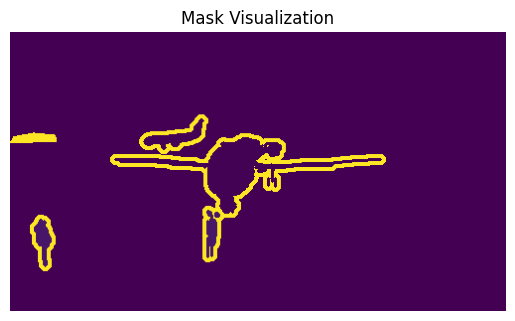

In [8]:
def show_mask_info(mask_path):
    """アノテーションマップを確認するための関数"""
    mask = Image.open(mask_path)
    mask_np = np.array(mask)

    # ユニーク値取得
    unique_values = np.unique(mask_np)

    print("ユニークなラベル一覧:", unique_values)
    print("ラベル数:", len(unique_values))

    # 表示
    plt.imshow(mask_np)
    plt.title("Mask Visualization")
    plt.axis("off")
    plt.show()

show_mask_info(train_anno_list[0])


### クラスDataTransformの作成
セマセグで守らなければならない鉄の掟：入力画像と正解マップに対して，全く同じ乱数シードで，全く同じ変形を行う事．

昔の`torchvision.transforms`は，1枚の画像しか受け取れなかったので自作クラスを作らなければならなかったが，`torchvision.transforms.v2`は複数画像に対応している．

In [9]:
# import torchvision.transforms.v2 as transforms_v2
# from torchvision.transforms import InterpolationMode
# from torchvision import tv_tensors

class DataTransform():
    """入力画像とアノテーションマップに対する前処理のクラス．訓練時は，データ拡張を行う．"""
    def __init__(self, input_size, color_mean, color_std, ignore_index):
        """
        Args:
            input_size (int): リサイズ後の大きさ．input_size * input_sizeにリサイズされる．
            color_mean (tuple(float, float, float)): 各色チャネルの平均値
            color_std (tuple(float, float, float)): 各色チャネルの標準偏差
            ignore_index (int): 学習時に無視するインデックス
        """
        self._ignore_index = ignore_index # __call__で使わないなら必要ない．
        self.transform = {
            'train': transforms_v2.Compose([
                transforms_v2.RandomZoomOut(fill={tv_tensors.Image: 0, tv_tensors.Mask: self._ignore_index}),
                transforms_v2.RandomResizedCrop(
                    size=(input_size, input_size), # 切り抜き後にリサイズするサイズ
                    scale=(0.5, 1.0), # scale: 面積割合の上下限
                    ratio=(3/4, 4/3) # ratio: アスペクト比の上下限
                ),
                transforms_v2.RandomRotation(
                    degrees=(-10, 10),
                    interpolation=InterpolationMode.BILINEAR, # tv_tensors.Maskの場合は，強制的にNEARESTで処理される．ソースコードを見ると確認できる．
                    fill={tv_tensors.Image: 0, tv_tensors.Mask: self._ignore_index}
                ),
                transforms_v2.RandomHorizontalFlip(p=0.5),
                transforms_v2.ToImage(),
                transforms_v2.ToDtype(
                    dtype={tv_tensors.Image: torch.float32, tv_tensors.Mask: torch.int64},
                    scale=True # 次のNormalizeに入れる平均値と標準偏差が，今回は[0, 1]前提であるため．おそらく
                ),
                transforms_v2.Normalize(color_mean, color_std)
            ]),
            'val': transforms_v2.Compose([
                transforms_v2.Resize(size=(input_size, input_size)), # trainでは，RandomResizeCropがリサイズしていた．
                transforms_v2.ToImage(),
                transforms_v2.ToDtype(
                    dtype={tv_tensors.Image: torch.float32, tv_tensors.Mask: torch.int64},
                    scale=True # 次のNormalizeに入れる平均値と標準偏差が，今回は[0, 1]前提であるため．
                ),
                transforms_v2.Normalize(color_mean, color_std)
            ])
        }
    
    def __call__(self, phase, img, anno_class_img):
        """
        Args:
            phase (str): 'train' or 'val'
        """
        # PIL画像をTV_Tensorsに変換して型情報を付与
        img = tv_tensors.Image(img)
        anno_class_img = tv_tensors.Mask(anno_class_img)

        img, anno_class_img = self.transform[phase](img, anno_class_img)

        # (1, H, W)になっているマスク画像のチャネル次元を潰して(H, W)にする．交差エントロピー関数が受け付けないので．
        anno_class_img = anno_class_img.squeeze(0)

        # 参考書の「255を0（背景）に書き換える」処理をここで再現
        # ignore_indexとして255をそのままLoss関数に渡す場合はこの処理は不要
        # anno_class_img[anno_class_img == self._ignore_index] = 0
        
        return img, anno_class_img.as_subclass(torch.Tensor) # Mask型から通常のTensor型に戻す．


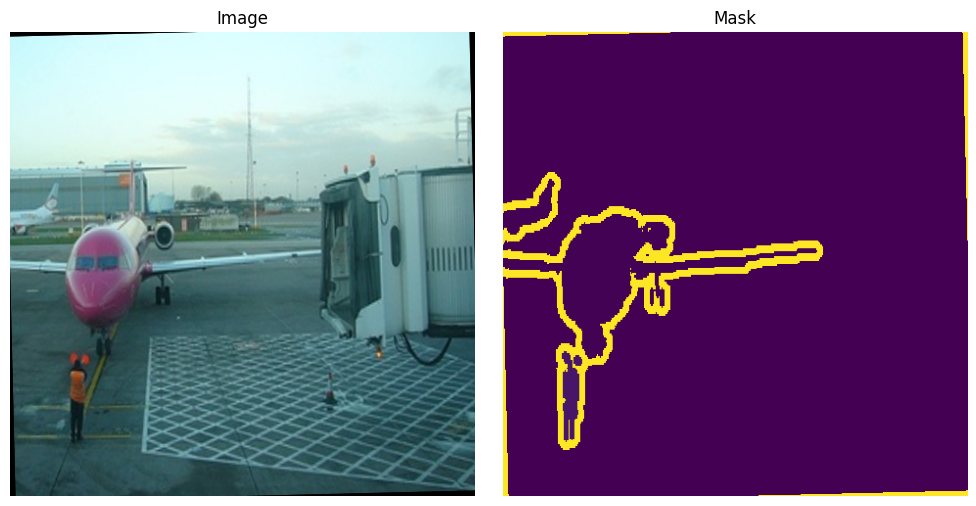

In [10]:
# 動作確認
idx = 0
img = Image.open(train_img_list[idx])
anno_class_img = Image.open(train_anno_list[idx])

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

transform = DataTransform(
    input_size=475,
    color_mean=tuple(mean),
    color_std=tuple(std),
    ignore_index=255
)
img, anno_class_img = transform('train', img, anno_class_img)

img = img.detach().numpy()
img = img.transpose(1, 2, 0)
img = (img * std) + mean
img = np.clip(img, 0, 1)

anno_class_img = anno_class_img.detach().numpy()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(anno_class_img.squeeze())
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


### クラスDatasetの作成

In [11]:
class VOCDataset(data.Dataset):
    """VOC2012のDataset"""
    def __init__(self, img_list, anno_list, phase, transform):
        self.img_list = img_list
        self.anno_list = anno_list
        self.phase = phase
        self.transform = transform
    
    def __len__(self):
        """画像の枚数を返す．"""
        return len(self.img_list)

    def __getitem__(self, index):
        """前処理をした画像のTensor形式のデータとアノテーションを取得"""
        img, anno_class_img = self.pull_item(index)
        return img, anno_class_img

    def pull_item(self, index):
        """画像のTensor形式のデータ・アノテーションを取得"""
        # 1. 画像読み込み
        image_file_path = self.img_list[index]
        img = Image.open(image_file_path) # (H, W, C)

        # 2. アノテーション画像読み込み
        anno_file_path = self.anno_list[index]
        anno_class_img = Image.open(anno_file_path) # (H, W)

        # 3. 前処理を実施
        img, anno_class_img = self.transform(self.phase, img, anno_class_img)

        return img, anno_class_img


In [12]:
# 動作確認
color_mean = (0.485, 0.456, 0.406)
color_std = (0.229, 0.224, 0.225)

train_dataset = VOCDataset(
    train_img_list,
    train_anno_list,
    phase='train',
    transform=DataTransform(input_size=475, color_mean=color_mean, color_std=color_std, ignore_index=255),
)
val_dataset = VOCDataset(
    valid_img_list,
    valid_anno_list,
    phase='val',
    transform=DataTransform(input_size=475, color_mean=color_mean, color_std=color_std, ignore_index=255),
)

# データの取り出し例
print(val_dataset.__getitem__(0)[0].shape) # (3, H, W)
print(val_dataset.__getitem__(0)[1].shape) # (1, H, W)
print(val_dataset.__getitem__(0))


torch.Size([3, 475, 475])
torch.Size([475, 475])
(Image([[[ 1.6495,  1.5125,  1.5639,  ...,  1.7523,  1.6838,  1.7009],
        [ 1.5639,  1.4269,  1.4783,  ...,  1.7009,  1.6324,  1.6495],
        [ 1.5468,  1.4098,  1.4612,  ...,  1.6838,  1.6153,  1.6324],
        ...,
        [-0.4911, -0.4911, -0.5082,  ...,  1.2557,  1.2043,  1.2214],
        [-0.5596, -0.4911, -0.4739,  ...,  1.2385,  1.2043,  1.2214],
        [-0.6281, -0.3883, -0.3541,  ...,  1.2385,  1.2043,  1.2214]],

       [[ 1.8158,  1.6758,  1.7283,  ...,  1.9209,  1.8508,  1.8683],
        [ 1.7283,  1.5882,  1.6408,  ...,  1.8683,  1.7983,  1.8158],
        [ 1.7108,  1.5707,  1.6232,  ...,  1.8508,  1.7808,  1.7983],
        ...,
        [-0.6001, -0.6001, -0.6176,  ...,  1.4132,  1.3431,  1.3431],
        [-0.6702, -0.6001, -0.5826,  ...,  1.3957,  1.3256,  1.3431],
        [-0.7402, -0.4951, -0.4601,  ...,  1.3957,  1.3256,  1.3431]],

       [[ 2.0300,  1.8905,  1.9428,  ...,  2.1346,  2.0648,  2.0823],
        [ 

### DataLoaderの作成

In [13]:
batch_size = 2 # 8だと，Colabの15GBで足りない．

train_dataloader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

dataloaders_dict = {'train': train_dataloader, 'val': val_dataloader}

# 動作の確認
batch_iterator = iter(dataloaders_dict['val']) # イタレータに変換
imges, anno_class_imges = next(batch_iterator) # 1番目の要素を取り出す
print(imges.size()) # torch.Size([8, 3, 475, 475])
print(anno_class_imges.size()) # torch.Size([8, 475, 475])


torch.Size([2, 3, 475, 475])
torch.Size([2, 475, 475])


## PSPNetの実装

### 1. Feature Module (Encoder)
ResNet-50っぽい．

#### FeatureMap_convolution
単純に以下のセットを繰り返すだけだよ．
- 畳み込み
- バッチ正規化
- マックスプーリング

In [14]:
class conv2DBatchNormRelu(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding, dilation, bias):
        super().__init__()

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, dilation, bias=bias)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.conv(x)
        x2 = self.batchnorm(x1)
        outputs = self.relu(x2)
        
        return outputs


In [15]:
class FeatureMap_convolution(nn.Module):
    def __init__(self):
        super().__init__()

        # 被りを持たせたストライド2の畳み込み：要約はしているが見落としは無く，解像度を半分にダウンサンプリングしている．
        in_channels, out_channels, kernel_size, stride, padding, dilation, bias = 3, 64, 3, 2, 1, 1, False
        self.cbnr_1 = conv2DBatchNormRelu(in_channels, out_channels, kernel_size, stride, padding, dilation, bias)

        in_channels, out_channels, kernel_size, stride, padding, dilation, bias = 64, 64, 3, 1, 1, 1, False
        self.cbnr_2 = conv2DBatchNormRelu(in_channels, out_channels, kernel_size, stride, padding, dilation, bias)

        in_channels, out_channels, kernel_size, stride, padding, dilation, bias = 64, 128, 3, 1, 1, 1, False
        self.cbnr_3 = conv2DBatchNormRelu(in_channels, out_channels, kernel_size, stride, padding, dilation, bias)

        # 隣のプーリング枠と1ピクセルずつ被りながら最大値を取り，画像の空間的な連続性を保った特徴マップを作る．位置不変性が，より強力になる．
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        x1 = self.cbnr_1(x)
        x2 = self.cbnr_2(x1)
        x3 = self.cbnr_3(x2)
        outputs = self.maxpool(x3)
        
        return outputs


#### ResidualBlockPSP
最初に`bottleNeckPSP`を通り，その後`bottleNeckIdentifyPSP`を繰り返す．

In [16]:
class conv2DBatchNorm(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding, dilation, bias):
        super().__init__()
        
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, dilation, bias=bias)
        self.batchnorm = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv(x)
        outputs = self.batchnorm(x)

        return outputs


In [17]:
class bottleNeckPSP(nn.Module):
    def __init__(self, in_channels, mid_channels, out_channels, stride, dilation):
        super().__init__()

        self.cbr_1 = conv2DBatchNormRelu(in_channels, mid_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False)
        self.cbr_2 = conv2DBatchNormRelu(mid_channels, mid_channels, kernel_size=3, stride=stride, padding=dilation, dilation=dilation, bias=False)
        self.cb_3 = conv2DBatchNorm(mid_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False)

        # スキップ結合
        self.cb_residual = conv2DBatchNorm(in_channels, out_channels, kernel_size=1, stride=stride, padding=0, dilation=1, bias=False)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        conv = self.cb_3(self.cbr_2(self.cbr_1(x)))
        residual = self.cb_residual(x)
        return self.relu(conv + residual)


In [18]:
class bottleNeckIdentityPSP(nn.Module):
    def __init__(self, in_channels, mid_channels, stride, dilation):
        super().__init__()

        self.cbr_1 = conv2DBatchNormRelu(in_channels, mid_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False)
        self.cbr_2 = conv2DBatchNormRelu(mid_channels, mid_channels, kernel_size=3, stride=1, padding=dilation, dilation=dilation, bias=False)
        self.cb_3 = conv2DBatchNorm(mid_channels, in_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        conv = self.cb_3(self.cbr_2(self.cbr_1(x)))
        residual = x
        return self.relu(conv + residual)


nn.Module を継承してこの処理（for文で可変長のブロックを繋げる処理）を書こうとすると，「nn.ModuleListという特殊な箱を用意しなければならない」うえに，「forward関数を自分で書いて，その中でfor文を回さなければならない」から，順番に処理すればよいだけの時は，nn.Sequentialを継承する．

In [19]:
class ResidualBlockPSP(nn.Sequential):
    def __init__(self, n_blocks, in_channels, mid_channels, out_channels, stride, dilation):
        super().__init__()

        # 初回のbottleNeckPSP
        self.add_module("block1", bottleNeckPSP(in_channels, mid_channels, out_channels, stride, dilation))

        # bottleNeckIdentifyPSPの繰り返し
        for i in range(n_blocks - 1):
            # モジュールを繰り返せるように，このモジュールの入出力チャネル数は一致する．
            self.add_module("block" + str(i+2), bottleNeckIdentityPSP(out_channels, mid_channels, stride, dilation))


### 2. Pyramid Pooling Module

In [20]:
class PyramidPooling(nn.Module):
    def __init__(self, in_channels, pool_sizes, height, width):
        super().__init__()

        # forwardで使用する「元の画像サイズ」
        self.height = height
        self.width = width

        # 各畳み込み層の出力チャネル数
        out_channels = int(in_channels / len(pool_sizes))

        # 各畳み込み層を作成
        # この実装方法は愚直すぎてfor文で書きたいところですが、分かりやすさを優先しています
        # pool_sizes: [6, 3, 2, 1]
        self.avpool_1 = nn.AdaptiveAvgPool2d(output_size=pool_sizes[0])
        self.cbr_1 = conv2DBatchNormRelu(in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False)

        self.avpool_2 = nn.AdaptiveAvgPool2d(output_size=pool_sizes[1])
        self.cbr_2 = conv2DBatchNormRelu(in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False)

        self.avpool_3 = nn.AdaptiveAvgPool2d(output_size=pool_sizes[2])
        self.cbr_3 = conv2DBatchNormRelu(in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False)

        self.avpool_4 = nn.AdaptiveAvgPool2d(output_size=pool_sizes[3])
        self.cbr_4 = conv2DBatchNormRelu(in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False)

    def forward(self, x):

        out1 = self.cbr_1(self.avpool_1(x))
        out1 = F.interpolate(out1, size=(self.height, self.width), mode="bilinear", align_corners=True)

        out2 = self.cbr_2(self.avpool_2(x))
        out2 = F.interpolate(out2, size=(self.height, self.width), mode="bilinear", align_corners=True)

        out3 = self.cbr_3(self.avpool_3(x))
        out3 = F.interpolate(out3, size=(self.height, self.width), mode="bilinear", align_corners=True)

        out4 = self.cbr_4(self.avpool_4(x))
        out4 = F.interpolate(out4, size=(self.height, self.width), mode="bilinear", align_corners=True)

        # 最終的に結合させる、dim=1でチャネル数の次元で結合
        output = torch.cat([x, out1, out2, out3, out4], dim=1)

        return output


### 3. Decoder Module and AuxLoss Module
Both the Decoder Module and AuxLoss Module have the same structure, since thier role is to perform pixel-wise classification from feature maps and then upsample.

In [21]:
class DecodePSPFeature(nn.Module):
    def __init__(self, height, width, n_classes):
        super().__init__()

        # forwardで使用する画像サイズ
        self.height = height
        self.width = width

        self.cbr = conv2DBatchNormRelu(in_channels=4096, out_channels=512, kernel_size=3, stride=1, padding=1, dilation=1, bias=False)
        self.dropout = nn.Dropout2d(p=0.1)
        self.classification = nn.Conv2d(in_channels=512, out_channels=n_classes, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x = self.cbr(x)
        x = self.dropout(x)
        x = self.classification(x)
        output = F.interpolate(x, size=(self.height, self.width), mode="bilinear", align_corners=True)

        return output


In [22]:
class AuxiliaryPSPlayers(nn.Module):
    def __init__(self, in_channels, height, width, n_classes):
        super().__init__()

        # forwardで使用する画像サイズ
        self.height = height
        self.width = width

        self.cbr = conv2DBatchNormRelu(in_channels=in_channels, out_channels=256, kernel_size=3, stride=1, padding=1, dilation=1, bias=False)
        self.dropout = nn.Dropout2d(p=0.1)
        self.classification = nn.Conv2d(in_channels=256, out_channels=n_classes, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x = self.cbr(x)
        x = self.dropout(x)
        x = self.classification(x)
        output = F.interpolate(x, size=(self.height, self.width), mode="bilinear", align_corners=True)

        return output


### PSPNet

In [23]:
class PSPNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        # パラメータ設定
        block_config = [3, 4, 6, 3]  # resnet50
        img_size = 475
        img_size_8 = 60  # img_sizeの1/8に

        # Featureモジュール
        self.feature_conv = FeatureMap_convolution()
        self.feature_res_1 = ResidualBlockPSP(n_blocks=block_config[0], in_channels=128,
                                              mid_channels=64, out_channels=256, stride=1, dilation=1)
        self.feature_res_2 = ResidualBlockPSP(n_blocks=block_config[1], in_channels=256,
                                              mid_channels=128, out_channels=512, stride=2, dilation=1)
        self.feature_dilated_res_1 = ResidualBlockPSP(n_blocks=block_config[2], in_channels=512,
                                                      mid_channels=256, out_channels=1024, stride=1, dilation=2)
        self.feature_dilated_res_2 = ResidualBlockPSP(n_blocks=block_config[3], in_channels=1024,
                                                      mid_channels=512, out_channels=2048, stride=1, dilation=4)

        # Pyramid Poolingモジュール
        self.pyramid_pooling = PyramidPooling(in_channels=2048, pool_sizes=[6, 3, 2, 1], height=img_size_8, width=img_size_8)

        # Decoderモジュール
        self.decode_feature = DecodePSPFeature(height=img_size, width=img_size, n_classes=n_classes)

        # AuxLossモジュール
        self.aux = AuxiliaryPSPlayers(in_channels=1024, height=img_size, width=img_size, n_classes=n_classes)

    def forward(self, x):
        x = self.feature_conv(x)
        x = self.feature_res_1(x)
        x = self.feature_res_2(x)
        x = self.feature_dilated_res_1(x)

        output_aux = self.aux(x) # Featureモジュールの途中をAuxLossモジュールへ

        x = self.feature_dilated_res_2(x)

        x = self.pyramid_pooling(x)
        output = self.decode_feature(x)

        return (output, output_aux)


### Sanity Check

In [24]:
# モデルの定義
net = PSPNet(n_classes=21)
net


PSPNet(
  (feature_conv): FeatureMap_convolution(
    (cbnr_1): conv2DBatchNormRelu(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (batchnorm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (cbnr_2): conv2DBatchNormRelu(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batchnorm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (cbnr_3): conv2DBatchNormRelu(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (batchnorm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (feature_res_1): ResidualBlockPSP(
    (block1): bottleNec

In [25]:
# ダミーデータの作成
batch_size = 2
dummy_img = torch.rand(batch_size, 3, 475, 475)

# 順伝播
outputs = net(dummy_img)
print(outputs)


(tensor([[[[-0.4027, -0.4525, -0.5024,  ..., -0.9055, -0.9703, -1.0351],
          [-0.3862, -0.4317, -0.4771,  ..., -0.8876, -0.9488, -1.0099],
          [-0.3697, -0.4108, -0.4518,  ..., -0.8698, -0.9273, -0.9847],
          ...,
          [-0.6485, -0.6626, -0.6768,  ..., -0.9290, -0.9625, -0.9960],
          [-0.7444, -0.7568, -0.7691,  ..., -0.9267, -0.9550, -0.9834],
          [-0.8404, -0.8509, -0.8614,  ..., -0.9244, -0.9475, -0.9707]],

         [[ 0.8634,  0.8144,  0.7654,  ...,  0.4147,  0.3933,  0.3720],
          [ 0.8364,  0.7933,  0.7503,  ...,  0.3840,  0.3582,  0.3324],
          [ 0.8094,  0.7723,  0.7352,  ...,  0.3534,  0.3231,  0.2929],
          ...,
          [ 0.3120,  0.2817,  0.2514,  ...,  0.5393,  0.5634,  0.5875],
          [ 0.3268,  0.2914,  0.2559,  ...,  0.5536,  0.5742,  0.5949],
          [ 0.3417,  0.3011,  0.2605,  ...,  0.5678,  0.5850,  0.6022]],

         [[-0.3294, -0.3764, -0.4234,  ..., -0.4270, -0.4307, -0.4343],
          [-0.3404, -0.3838, 

## Training and Validation with Fine-tuning

### Loading Pretrained Weights and Replacing Conv2D Layer for Classification

In [215]:
# ファインチューニングでPSPNetを作成
# ADE20Kデータセットの学習済みモデルを使用、ADE20Kはクラス数が150です。
net = PSPNet(n_classes=150)

# ADE20K学習済みパラメータをロード
state_dict = torch.load("./weights/pspnet50_ADE20K.pth")
net.load_state_dict(state_dict)

# 分類用の畳み込み層を、出力数21のものにつけかえる
n_classes = 21
net.decode_feature.classification = nn.Conv2d(in_channels=512, out_channels=n_classes, kernel_size=1, stride=1, padding=0)
net.aux.classification = nn.Conv2d(in_channels=256, out_channels=n_classes, kernel_size=1, stride=1, padding=0)

# 付け替えた畳み込み層を初期化する。活性化関数がシグモイド関数なのでXavierを使用する。
def weights_init(m):
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_normal_(m.weight.data)
        if m.bias is not None:  # バイアス項がある場合
            nn.init.constant_(m.bias, 0.0)

net.decode_feature.classification.apply(weights_init)
net.aux.classification.apply(weights_init)

print('ネットワーク設定完了：学習済みの重みをロードしました。')


ネットワーク設定完了：学習済みの重みをロードしました。


### Loss Function Definition

In [216]:
class PSPLoss(nn.Module):
    """PSPNetの損失関数クラス"""
    def __init__(self, aux_weight=0.4, ignore_index=255):
        super().__init__()
        self.aux_weight = aux_weight # aux_lossの重み
        self.ignore_index = ignore_index

    def forward(self, outputs, targets):
        """
        損失関数の計算

        Args
        ----------
        outputs : PSPNetの出力(tuple)
            (output=torch.Size([num_batch, 21, 475, 475]), output_aux=torch.Size([num_batch, 21, 475, 475]))。

        targets : [num_batch, 475, 475]
            正解のアノテーション情報

        Returns
        -------
        loss : テンソル
            損失の値
        """

        loss = F.cross_entropy(outputs[0], targets, reduction='mean', ignore_index=self.ignore_index)
        loss_aux = F.cross_entropy(outputs[1], targets, reduction='mean', ignore_index=self.ignore_index)

        return loss + (self.aux_weight * loss_aux)

criterion = PSPLoss(aux_weight=0.4, ignore_index=255)


### Epoch-wise Learning Rate Scheduling with PyTorch's Scheduler

In [217]:
# ファインチューニングなので、学習済みパラメータの学習率は小さく。
optimizer = optim.SGD([
    {'params': net.feature_conv.parameters(), 'lr': 1e-3},
    {'params': net.feature_res_1.parameters(), 'lr': 1e-3},
    {'params': net.feature_res_2.parameters(), 'lr': 1e-3},
    {'params': net.feature_dilated_res_1.parameters(), 'lr': 1e-3},
    {'params': net.feature_dilated_res_2.parameters(), 'lr': 1e-3},
    {'params': net.pyramid_pooling.parameters(), 'lr': 1e-3},
    {'params': net.decode_feature.parameters(), 'lr': 1e-2},
    {'params': net.aux.parameters(), 'lr': 1e-2},
], momentum=0.9, weight_decay=0.0001)

# スケジューラーの設定
def lambda_epoch(epoch):
    """
    上に凸．序盤は高めで，終盤で強めにブレーキ．
    
    - Epoch 0: (1 - 0)^0.9 = 1.0
    - Epoch 15: (1 - 0.5)^0.9 ≒ 0.536
    - Epoch 30: (1 - 1)^0.9 = 0.0
    """
    max_epoch = 30
    return np.pow((1 - (epoch / max_epoch)), 0.9)

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_epoch)


### Defining a Function for Training
「Asynchronized Multi-GPU Batch Normalizationに近い動きを実装している」とあるが，よくわからない．バッチ正規化において，バッチサイズが小さすぎることによる統計量の揺れには対処できていないような気がする？

In [ ]:
def train_model(net, dataloaders_dict, criterion, scheduler, optimizer, num_epochs):
    # GPUが使えるかを確認
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("device:", device)

    net.to(device)

    # ネットワークがある程度固定であれば，高速化させる．
    torch.backends.cudnn.benchmark = True

    # 画像の枚数
    num_train_imgs = len(dataloaders_dict["train"].dataset)
    num_val_imgs = len(dataloaders_dict["val"].dataset)

    logs = []
    scaler = GradScaler('cuda') # AMPのスケーラーを初期化
    batch_multiplier = 6 # multiple minibatch

    epoch_bar = tqdm(range(num_epochs), desc="Total Progress", leave=True)

    for epoch in epoch_bar:
        epoch_train_loss = 0.0  # epochの損失和
        epoch_val_loss = 0.0  # epochの損失和

        # epochごとの訓練と検証のループ
        for phase in ['train', 'val']:
            if phase == 'train':
                net.train()
                optimizer.zero_grad()
            else:
                if((epoch+1) % 5 == 0):
                    net.eval()
                else:
                    # 検証は5回に1回だけ行う
                    continue
            
            # データローダーの長さを取得（最後のバッチ判定用）
            epoch_batches = len(dataloaders_dict[phase])

            batch_iterator = tqdm(dataloaders_dict[phase], desc=f"Epoch {epoch+1}/{num_epochs} [{phase}]", leave=False)

            # データローダーからminibatchずつ取り出すループ
            for i, (imges, anno_class_imges) in enumerate(batch_iterator):
                # ミニバッチがサイズが1だと、バッチノーマライゼーションでエラーになるのでさける
                # issue #186より不要なのでコメントアウト
                # if imges.size()[0] == 1:
                #     continue

                # GPUが使えるならGPUにデータを送る
                imges = imges.to(device)
                anno_class_imges = anno_class_imges.to(device)

                # 順伝搬（forward）計算
                with torch.set_grad_enabled(phase == 'train'):
                    # AMPブロック：この中だけfloat16で爆速計算される．
                    with autocast('cuda'):
                        outputs = net(imges)
                        loss_batch = criterion(outputs, anno_class_imges.long()) # batch_size枚の平均loss
                        loss_for_grad = loss_batch / batch_multiplier # (batch_size * batch_multiplier)枚の平均loss

                    # 訓練時はバックプロパゲーション
                    if phase == 'train':
                        scaler.scale(loss_for_grad).backward() # backwardもscalerを経由

                        epoch_train_loss += loss_batch.item() * imges.size(0) # バッチ平均損失 * バッチサイズ = 当該バッチの合計損失
                        
                        batch_iterator.set_postfix({"Batch Loss": f"{loss_batch.item():.4f}"})

                        # multiple minibatchでのパラメータの更新
                        # 「batch_multiplier回に1回」または「最後のバッチ」の時だけパラメータを更新する．
                        if (i + 1) % batch_multiplier == 0 or (i + 1) == epoch_batches:
                            scaler.step(optimizer)
                            scaler.update()
                            optimizer.zero_grad()

                    # 検証時
                    else:
                        epoch_val_loss += loss_batch.item() * imges.size(0) # バッチ平均損失 * バッチサイズ = 当該バッチの合計損失
                        batch_iterator.set_postfix({"Batch Loss": f"{loss_batch.item():.4f}"})
            
            # スケジューラは train フェーズの「一番最後（全バッチ終了後）」に更新
            if phase == 'train':
                scheduler.step()

        # エポック終了時の処理
        train_loss_avg = epoch_train_loss / num_train_imgs
        val_loss_avg = epoch_val_loss / num_val_imgs if ((epoch+1) % 5 == 0) else 0.0
        
        # 外側のプログレスバーの横にエポックごとのLossを固定表示
        val_str = f"{val_loss_avg:.4f}" if ((epoch+1) % 5 == 0) else "Skip"
        epoch_bar.set_postfix({"Train Loss": f"{train_loss_avg:.4f}", "Val Loss": val_str})

        # ログを保存
        # 全バッチのLossの合計を，全画像の枚数で割る．
        log_epoch = {'epoch': epoch+1, 'train_loss': train_loss_avg, 'val_loss': val_loss_avg}
        logs.append(log_epoch)
        df = pd.DataFrame(logs)
        
        save_dir = "/content/drive/MyDrive/Deep_Learning/PSPNet/"
        os.makedirs(save_dir, exist_ok=True)
        csv_path = os.path.join(save_dir, "log_output.csv")
        df.to_csv(csv_path, index=False)

    # 最後のネットワークを保存する
    save_dir = "/content/drive/MyDrive/Deep_Learning/PSPNet/"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f'pspnet50_{epoch+1}.pth')
    torch.save(net.state_dict(), save_path)
    print(f"モデルの重みをGoogle Driveに保存しました: {save_path}")


### Running the Training Loop

In [ ]:
# 学習・検証を実行する
num_epochs = 10
train_model(net, dataloaders_dict, criterion, scheduler, optimizer, num_epochs=num_epochs)


device: cuda:0


/tmp/ipykernel_879/2453657369.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # AMPのスケーラーを初期化


Total Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 [train]:   0%|          | 0/732 [00:00<?, ?it/s]

/tmp/ipykernel_879/2453657369.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 2/10 [train]:   0%|          | 0/732 [00:00<?, ?it/s]

: 

### Learning Curve

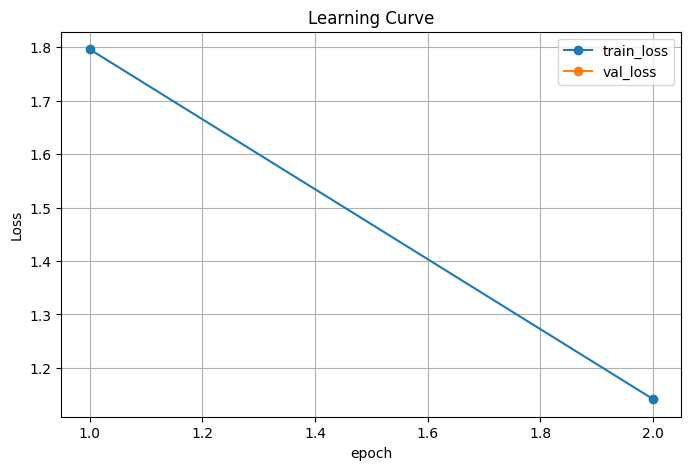

In [25]:
df = pd.read_csv("/content/drive/MyDrive/Deep_Learning/PSPNet/log_output.csv")

# グラフが0にガクンと落ちるのを防ぐため，0.0をNaN（欠損値）に変換．
df['val_loss'] = df['val_loss'].replace(0.0, float('nan'))

# プロット（Pandasの組み込み機能）
df.plot(x='epoch', y=['train_loss', 'val_loss'], marker='o', figsize=(8, 5), grid=True)

plt.title('Learning Curve')
plt.ylabel('Loss')
plt.show()


## Inference

### Loading Pretrained PSPNet

In [44]:
net = PSPNet(n_classes=21)

pth_dir = "/content/drive/MyDrive/Deep_Learning/PSPNet/pspnet50_10.pth"
state_dict = torch.load(pth_dir, map_location='cpu') # GPUで保存したモデルをCPUで使用
net.load_state_dict(state_dict)

print('ネットワーク設定完了：学習済みの重みをロードしました')


ネットワーク設定完了：学習済みの重みをロードしました


### Running Inference

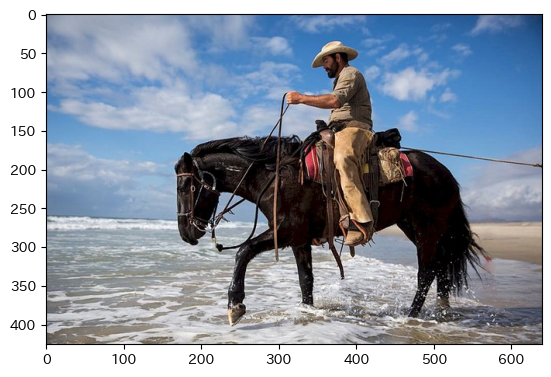

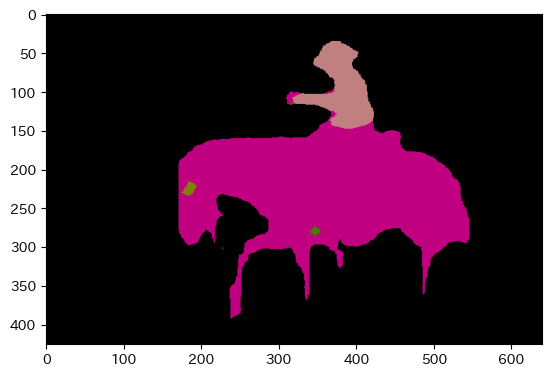

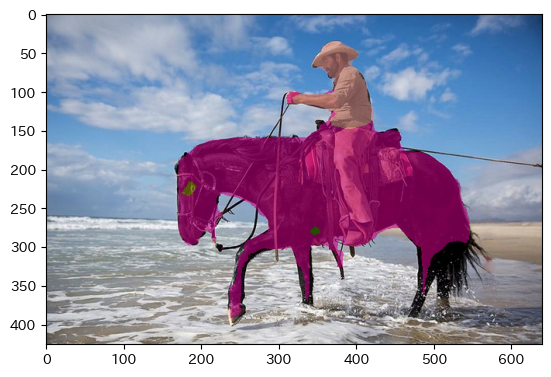

In [45]:
# 1. 元画像の表示
image_file_path = "/content/drive/MyDrive/Deep_Learning/PSPNet/cowboy-757575_640.jpg"
img = Image.open(image_file_path) # (H, W, C)
img_width, img_height = img.size
plt.imshow(img)
plt.show()

# 2. 前処理クラスの作成
color_mean = (0.485, 0.456, 0.406)
color_std = (0.229, 0.224, 0.225)
transform = DataTransform(input_size=475, color_mean=color_mean, color_std=color_std, ignore_index=255)

# 3. 前処理
# 適当なアノテーション画像を用意し、さらにカラーパレットの情報を抜き出す
anno_file_path = valid_anno_list[0]
anno_class_img = Image.open(anno_file_path)   # [高さ][幅]
p_palette = anno_class_img.getpalette()
phase = "val"
img, anno_class_img = transform(phase, img, anno_class_img)

# 4. PSPNetで推論する
net.eval()
x = img.unsqueeze(0)  # ミニバッチ化：torch.Size([1, 3, 475, 475])
outputs = net(x)
y = outputs[0]  # AuxLoss側は無視 yのサイズはtorch.Size([1, 21, 475, 475])

# 5. PSPNetの出力から最大クラスを求め、カラーパレット形式にし、画像サイズを元に戻す
y = y[0].detach().numpy()  # y：torch.Size([1, 21, 475, 475])
# print(y.shape) # (21, 475, 475)
y = np.argmax(y, axis=0) # (475, 475)
anno_class_img = Image.fromarray(np.uint8(y)).convert("P")
anno_class_img = anno_class_img.resize((img_width, img_height), Image.NEAREST)
anno_class_img.putpalette(p_palette)
plt.imshow(anno_class_img)
plt.show()

# 6. 画像を透過させて重ねる
trans_img = Image.new('RGBA', anno_class_img.size, (0, 0, 0, 0))
anno_class_img = anno_class_img.convert('RGBA')  # カラーパレット形式をRGBAに変換

for x in range(img_width):
    for y in range(img_height):
        # 推論結果画像のピクセルデータを取得
        pixel = anno_class_img.getpixel((x, y))
        r, g, b, a = pixel

        # (0, 0, 0)の背景ならそのままにして透過させる
        if pixel[0] == 0 and pixel[1] == 0 and pixel[2] == 0:
            continue
        else:
            # それ以外の色は用意した画像にピクセルを書き込む
            trans_img.putpixel((x, y), (r, g, b, 150))
            # 150は透過度の大きさを指定している

img = Image.open(image_file_path)   # [高さ][幅][色RGB]
result = Image.alpha_composite(img.convert('RGBA'), trans_img)
plt.imshow(result)
plt.show()


In [46]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def display_segmentation_results_with_legend(image_paths, net, transform, p_palette, device="cuda:0"):
    net.to(device)
    net.eval()

    for path in image_paths:
        img = Image.open(path).convert('RGB')
        img_width, img_height = img.size
        
        dummy_anno = Image.new('L', img.size, 0) 
        img_tensor, _ = transform("val", img, dummy_anno)
        x = img_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = net(x)
            y = outputs[0]

        y = y[0].cpu().numpy()
        y = np.argmax(y, axis=0)

        # --- 凡例（Legend）用のパッチを作成 ---
        unique_ids = np.unique(y)
        legend_patches = []
        for class_id in unique_ids:
            if class_id == 0:
                continue # 背景(0)は凡例から除外（お好みで）
            
            # getpalette() は [r, g, b, r, g, b...] という1次元リストなので、3倍してRGBを取得
            r = p_palette[class_id * 3]
            g = p_palette[class_id * 3 + 1]
            b = p_palette[class_id * 3 + 2]
            
            # matplotlib用にHEXカラーコード（#RRGGBB）または0-1のRGBタプルに変換
            color_hex = f"#{r:02x}{g:02x}{b:02x}"
            
            # パッチを作成
            patch = mpatches.Patch(color=color_hex, label=VOC_CLASSES[class_id])
            legend_patches.append(patch)
        # ------------------------------------

        anno_class_img = Image.fromarray(np.uint8(y)).convert("P")
        anno_class_img = anno_class_img.resize((img_width, img_height), Image.NEAREST)
        anno_class_img.putpalette(p_palette)

        anno_rgba = np.array(anno_class_img.convert('RGBA'))
        is_bg = (anno_rgba[:, :, 0] == 0) & (anno_rgba[:, :, 1] == 0) & (anno_rgba[:, :, 2] == 0)
        anno_rgba[:, :, 3] = np.where(is_bg, 0, 150)
        trans_img = Image.fromarray(anno_rgba)

        base_img = Image.open(path).convert('RGBA')
        result = Image.alpha_composite(base_img, trans_img)

        plt.figure(figsize=(10, 8))
        plt.imshow(result)
        plt.title(f"Result: {path.split('/')[-1]}", fontsize=14)
        plt.axis('off')
        
        # 凡例を描画（グラフの右外側に配置）
        if legend_patches:
            plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=12)
            
        plt.tight_layout()
        plt.show()

# 実行
# display_segmentation_results_with_legend(my_image_paths, net, transform, p_palette)


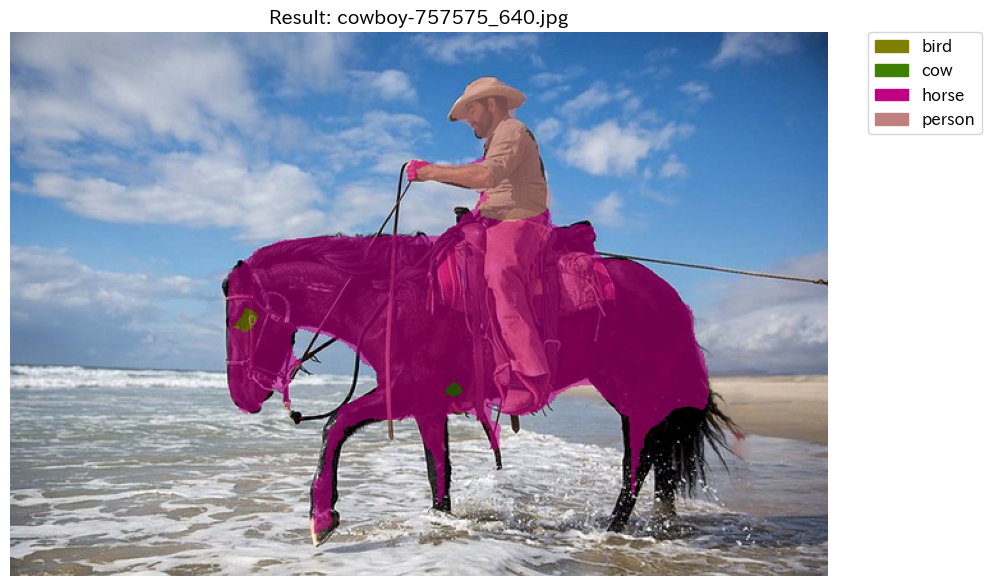

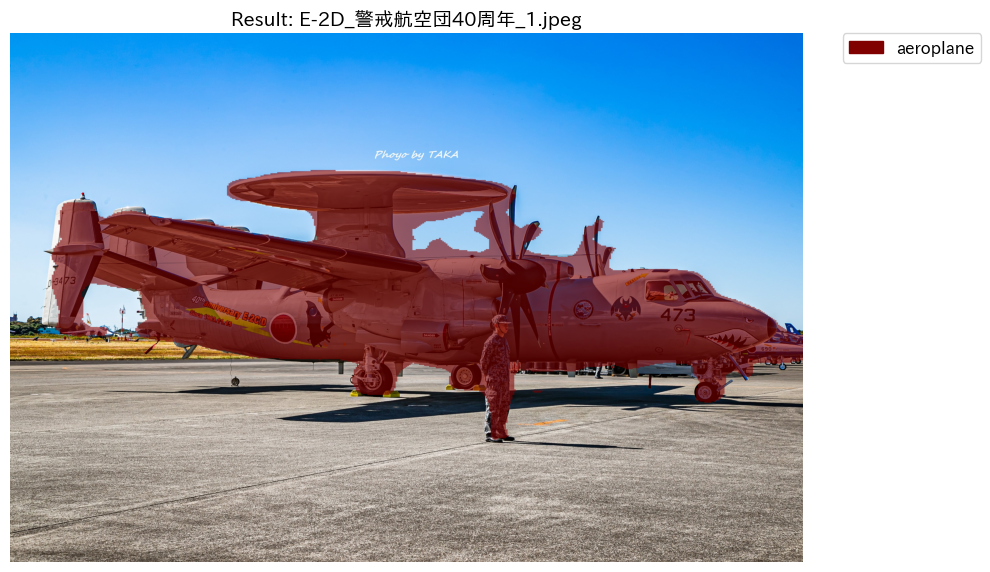

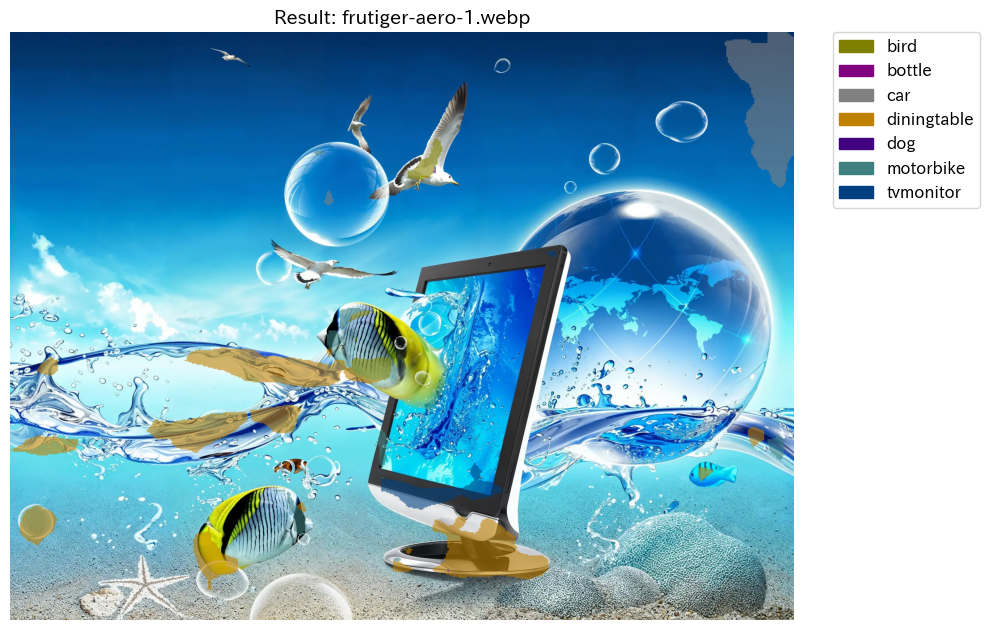

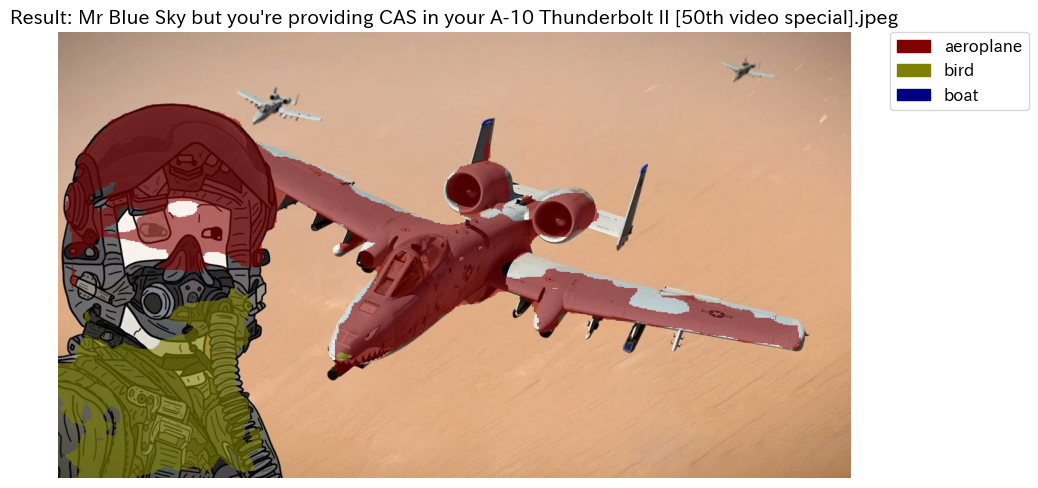

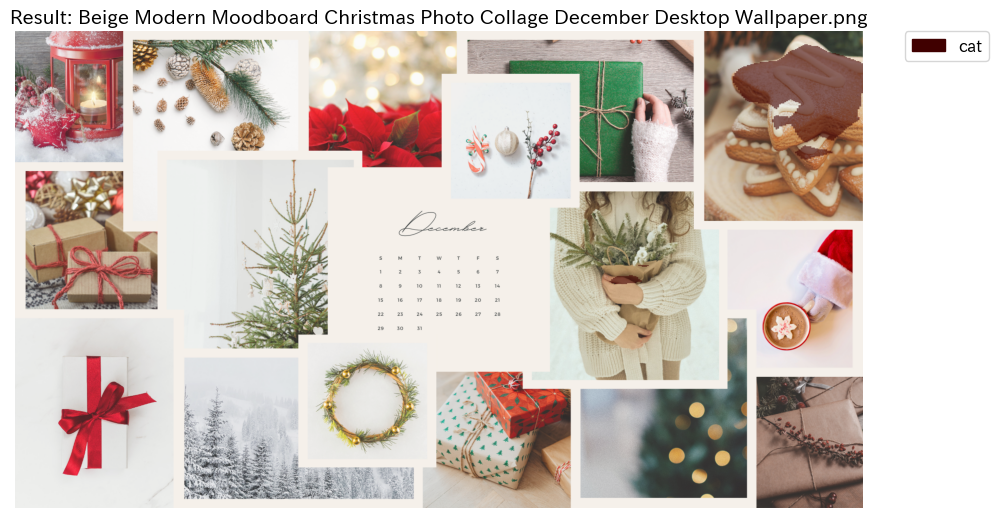

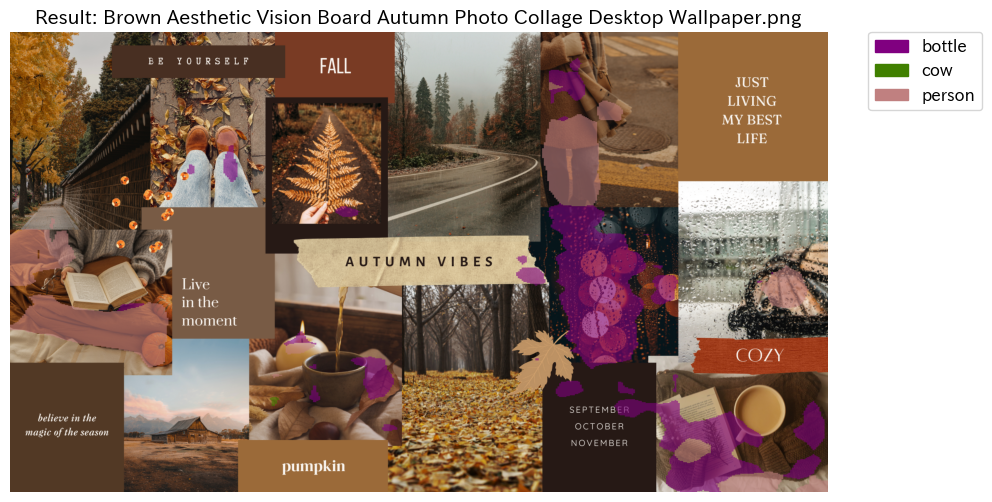

In [47]:
my_image_paths = [
    "/content/drive/MyDrive/Deep_Learning/PSPNet/cowboy-757575_640.jpg",
    "/content/drive/MyDrive/Deep_Learning/PSPNet/E-2D_警戒航空団40周年_1.jpeg",
    "/content/drive/MyDrive/Deep_Learning/PSPNet/frutiger-aero-1.webp",
    "/content/drive/MyDrive/Deep_Learning/PSPNet/Mr Blue Sky but you're providing CAS in your A-10 Thunderbolt II [50th video special].jpeg",
    "/content/drive/MyDrive/Deep_Learning/PSPNet/Beige Modern Moodboard Christmas Photo Collage December Desktop Wallpaper.png",
    "/content/drive/MyDrive/Deep_Learning/PSPNet/Brown Aesthetic Vision Board Autumn Photo Collage Desktop Wallpaper.png",
]

# 先にパレット情報を取得しておく．（1回だけでOK）
anno_file_path = valid_anno_list[0]
p_palette = Image.open(anno_file_path).getpalette()

# 一気に推論＆表示を実行！
display_segmentation_results_with_legend(my_image_paths, net, transform, p_palette, device="cuda:0")
